# Wav2Vec2.0 Embedding Pipeline — PD / HC

Full pipeline:  **Extract → Aggregate → Linear Probe → Visualize**

Code structure follows `external/fairseq/examples/wav2vec/wav2vec_featurize.py`  
with references noted inline for every borrowed pattern.


In [1]:
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch", "torchaudio", "transformers", "scipy",
     "scikit-learn", "tqdm", "matplotlib"],
    check=True
)
print("All packages ready.")


All packages ready.


In [2]:
import csv, glob, os
from math import gcd

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import torch
import tqdm
from scipy.signal import resample_poly
from torch import nn
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

CLASSES   = ["PD", "HC"]
SEGMENTS  = ["early", "middle", "late"]
TARGET_SR = 16_000

ROOT      = os.path.abspath(os.path.join(os.getcwd(), ".."))
SEG_ROOT  = os.path.join(ROOT,         "segments")
EMB_ROOT  = os.path.join(os.getcwd(),  "embeddings")
AGG_ROOT  = os.path.join(os.getcwd(),  "embeddings_aggregated")
META_PATH = os.path.join(os.getcwd(),  "metadata.csv")
META_AGG  = os.path.join(os.getcwd(),  "metadata_aggregated.csv")
PLOTS_DIR = os.path.join(os.getcwd(),  "plots")

print(f"Segments root : {SEG_ROOT}")
print(f"Embeddings out: {EMB_ROOT}")


Segments root : /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/segments
Embeddings out: /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/embeddings


In [3]:
# Adapted from:
#   external/fairseq/examples/wav2vec/wav2vec_featurize.py  L25-31
#
# Original (L28-30):
#   wav, sr = sf.read(fname)
#   assert sr == 16e3
#   return wav, 16e3
#
# Changes:
#   - always_2d=True + mono mix  (mPower files may be multi-channel)
#   - resample_poly to 16 kHz    (mPower FLAC files are 44.1 kHz)

def read_audio(fname: str) -> tuple[np.ndarray, int]:
    wav, sr = sf.read(fname, always_2d=True)          # L28
    if wav.shape[1] > 1:
        wav = wav.mean(axis=1)
    else:
        wav = wav[:, 0]
    wav = wav.astype(np.float32)
    if sr != TARGET_SR:
        g   = gcd(sr, TARGET_SR)
        wav = resample_poly(wav, TARGET_SR // g, sr // g).astype(np.float32)
    return wav, TARGET_SR

# quick smoke test
_wav, _sr = read_audio(next(
    p for c in CLASSES for s in SEGMENTS
    for p in glob.glob(os.path.join(SEG_ROOT, c, s, "*.flac"))[:1]
))
print(f"read_audio OK  shape={_wav.shape}  sr={_sr}")


read_audio OK  shape=(48000,)  sr=16000


In [4]:
# Adapted from:
#   external/fairseq/examples/wav2vec/wav2vec_featurize.py  L34-50
#
# Original class name  : PretrainedWav2VecModel (wav2vec 1.0)
# Our class name       : PretrainedWav2Vec2Model (wav2vec 2.0)
#
# Original L38  : model, cfg, task = fairseq.checkpoint_utils.load_model_ensemble_and_task([fname])
# Our equivalent: Wav2Vec2Model.from_pretrained(model_name_or_path)
#
# Original L46  : z = self.model.feature_extractor(x)
# Our equivalent: outputs.extract_features          (CNN output, 512-d)
#
# Original L48  : c = self.model.feature_aggregator(z)
# Our equivalent: outputs.last_hidden_state          (transformer output, 768-d)
#
# The z / c names are kept unchanged so the rest of the pipeline
# stays in sync with the fairseq script.

class PretrainedWav2Vec2Model(nn.Module):
    def __init__(self, model_name_or_path: str):
        super().__init__()
        self.feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name_or_path)
        self.model = Wav2Vec2Model.from_pretrained(model_name_or_path)
        self.model.eval()                                          # L40: model.eval()

    def forward(self, wav: np.ndarray, sr: int):
        inputs = self.feature_extractor(
            wav, sampling_rate=sr, return_tensors="pt", padding=True
        )
        input_values = inputs.input_values.to(
            next(self.model.parameters()).device
        )
        with torch.no_grad():                                      # L45: with torch.no_grad()
            outputs = self.model(input_values)
        z = outputs.extract_features.squeeze(0).cpu().numpy()     # L47: z = feature_extractor(x)
        c = outputs.last_hidden_state.squeeze(0).cpu().numpy()    # L49: c = feature_aggregator(z)
        return z, c

print("PretrainedWav2Vec2Model defined.")


PretrainedWav2Vec2Model defined.


In [5]:
# Taken from:
#   external/fairseq/examples/wav2vec/wav2vec_featurize.py  L80-92
#
# L83-85 (original):
#   self.gpu   = gpu
#   self.model = PretrainedWav2VecModel(fname).cuda(gpu)
# Changed .cuda(gpu) -> device-agnostic so it runs on CPU when no CUDA.
#
# L87-92 (original, kept in spirit):
#   def __call__(self, x):
#       x = torch.from_numpy(x).float().cuda(self.gpu)
#       with torch.no_grad():
#           z, c = self.model(x.unsqueeze(0))
#       return z.squeeze(0).cpu().numpy(), c.squeeze(0).cpu().numpy()
# The tensor casting / device step is now inside PretrainedWav2Vec2Model.forward().

class Prediction:
    def __init__(self, model_name_or_path: str, gpu: int = 0):    # L83
        self.device = f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
        self.model  = PretrainedWav2Vec2Model(model_name_or_path)
        self.model.to(self.device)

    def __call__(self, wav: np.ndarray, sr: int):                  # L87
        return self.model(wav, sr)

print("Prediction defined.")


Prediction defined.


In [6]:
# Adapted from:
#   external/fairseq/examples/wav2vec/wav2vec_featurize.py  L111-220
#
# Original class structure preserved:
#   __init__             L123-148  model + dataset bookkeeping
#   _progress            L151-154  optional tqdm wrapper
#   require_output_path  L156-158  os.makedirs
#   input_fnames         L189-191  glob *.{ext}  ->  we glob *.flac per (cls, seg)
#   write_features       L196-214  core extraction loop
#   __repr__             L216-220
#
# Key differences:
#   - input is <root>/<class>/<segment>/*.flac  (not <root>/<split>/*.wav)
#   - output is .npy mean-pool + _seq.npy full  (not .h5context via H5Writer L95-108)
#   - metadata list replaces copy_labels()      (L178-187)
#   - resume logic: skip files whose .npy already exists on disk

class EmbeddingDatasetWriter:
    def __init__(self, input_root, output_root, model_fname,       # L123
                 gpu=0, verbose=True, use_feat=False):
        assert os.path.isdir(input_root), f"Not found: {input_root}"
        self.input_root  = input_root
        self.output_root = output_root
        self.model_fname = model_fname
        self.verbose     = verbose
        self.use_feat    = use_feat
        self.model       = Prediction(model_fname, gpu)            # L138
        self.metadata    = []

    def _progress(self, iterable, **kwargs):                       # L151-154
        return tqdm.tqdm(iterable, **kwargs) if self.verbose else iterable

    def _input_fnames(self, cls, seg):                             # mirrors L189-191
        return sorted(glob.glob(os.path.join(self.input_root, cls, seg, "*.flac")))

    def _output_dir(self, cls, seg):
        return os.path.join(self.output_root, cls, seg)

    def require_output_dirs(self):                                 # mirrors L156-158
        for cls in CLASSES:
            for seg in SEGMENTS:
                os.makedirs(self._output_dir(cls, seg), exist_ok=True)

    def write_features(self):                                      # L196-214
        for cls in CLASSES:
            for seg in SEGMENTS:
                fnames  = self._input_fnames(cls, seg)
                out_dir = self._output_dir(cls, seg)
                skipped = 0
                for fpath in self._progress(fnames, desc=f"{cls}/{seg}", unit="file"):
                    stem          = os.path.splitext(os.path.basename(fpath))[0]
                    mean_path     = os.path.join(out_dir, f"{stem}.npy")
                    seq_path      = os.path.join(out_dir, f"{stem}_seq.npy")
                    original_stem = "_".join(stem.split("_")[:-1])

                    # resume: if both outputs exist, just rebuild metadata entry
                    if os.path.isfile(mean_path) and os.path.isfile(seq_path):
                        skipped += 1
                        self.metadata.append({
                            "filename": os.path.basename(fpath), "class": cls,
                            "segment": seg, "original_stem": original_stem,
                            "embedding_path": mean_path, "seq_path": seq_path,
                        })
                        continue

                    wav, sr  = read_audio(fpath)                   # L210
                    z, c     = self.model(wav, sr)                 # L211
                    features = z if self.use_feat else c           # L212
                    mean_vec = features.mean(axis=0)
                    np.save(mean_path, mean_vec)
                    np.save(seq_path,  features)
                    self.metadata.append({
                        "filename": os.path.basename(fpath), "class": cls,
                        "segment": seg, "original_stem": original_stem,
                        "embedding_path": mean_path, "seq_path": seq_path,
                    })

                if skipped:
                    print(f"  {cls}/{seg}: {skipped} files already done, skipped.")

    def write_metadata(self, path):
        fields = ["filename","class","segment","original_stem","embedding_path","seq_path"]
        with open(path, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=fields)
            w.writeheader(); w.writerows(self.metadata)
        print(f"Metadata  ->  {path}")

    def __repr__(self):                                            # L216-220
        n = sum(len(self._input_fnames(c, s)) for c in CLASSES for s in SEGMENTS)
        return (f"EmbeddingDatasetWriter ({n} files)\n"
                f"\tinput_root  : {self.input_root}\n"
                f"\toutput_root : {self.output_root}\n"
                f"\tmodel       : {self.model_fname}")

print("EmbeddingDatasetWriter defined (resume-enabled).")

EmbeddingDatasetWriter defined (resume-enabled).


## Step 1 — Extract Embeddings

Mirrors the main execution block at:
`external/fairseq/examples/wav2vec/wav2vec_featurize.py  L223-249`

Original loops over `args.split` and creates one writer per split (L227-243).  
Here a single writer walks all CLASSES × SEGMENTS in one call.


In [7]:
MODEL = "facebook/wav2vec2-base"   # swap for a local .pt path if needed

# L229-237 in original: EmbeddingDatasetWriter(input_root=args.input, ...)
writer = EmbeddingDatasetWriter(
    input_root  = SEG_ROOT,
    output_root = EMB_ROOT,
    model_fname = MODEL,
    gpu         = 0,
    use_feat    = False,
)
print(writer)
writer.require_output_dirs()           # L240: writer.require_output_path()

print("\nExtracting embeddings...")
writer.write_features()                # L243: writer.write_features()
print("Done.\n")

writer.write_metadata(META_PATH)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


EmbeddingDatasetWriter (3741 files)
	input_root  : /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/segments
	output_root : /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/embeddings
	model       : facebook/wav2vec2-base

Extracting embeddings...


HC/late: 100%|██████████| 909/909 [04:06<00:00,  3.68file/s]

Done.

Metadata  ->  /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/metadata.csv


## Step 2 — Aggregate Segment Embeddings

Combine `early / middle / late` vectors for each original recording.  
- `concat` → 3 × 768 = **2304-d** vector  
- `mean`   → **768-d** vector


In [8]:
import pandas as pd

def load_seg_emb(root, cls, seg, stem):
    path = os.path.join(root, cls, seg, f"{stem}.npy")
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    return np.load(path)

def run_aggregation(emb_root, agg_root, strategy="concat"):
    os.makedirs(agg_root, exist_ok=True)
    records = []
    for cls in CLASSES:
        early_dir = os.path.join(emb_root, cls, "early")
        stems = sorted(
            os.path.splitext(f)[0].removesuffix("_early")
            for f in os.listdir(early_dir)
            if f.endswith(".npy") and not f.endswith("_seq.npy")
        )
        out_cls = os.path.join(agg_root, cls)
        os.makedirs(out_cls, exist_ok=True)
        for orig_stem in tqdm.tqdm(stems, desc=cls, unit="file"):
            vecs, skip = [], False
            for seg in SEGMENTS:
                try:
                    vecs.append(load_seg_emb(emb_root, cls, seg, f"{orig_stem}_{seg}"))
                except FileNotFoundError:
                    skip = True; break
            if skip:
                continue
            agg = np.concatenate(vecs) if strategy == "concat" else np.stack(vecs).mean(0)
            out = os.path.join(out_cls, f"{orig_stem}_{strategy}.npy")
            np.save(out, agg)
            records.append({
                "original_stem":  orig_stem,
                "class":          cls,
                "strategy":       strategy,
                "embedding_dim":  agg.shape[0],
                "embedding_path": out,
            })
    return pd.DataFrame(records)

agg_df = run_aggregation(EMB_ROOT, AGG_ROOT, strategy="concat")
agg_df.to_csv(META_AGG, index=False)
print(f"Aggregated {len(agg_df)} recordings  ->  {META_AGG}")


HC: 100%|██████████| 909/909 [00:01<00:00, 826.17file/s]

Aggregated 1247 recordings  ->  /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/metadata_aggregated.csv


## Step 3 — Linear Probe

5-fold stratified cross-validation with `StandardScaler + LogisticRegression`.  
One probe per segment + one on the aggregated 2304-d vectors.


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def load_X_y(df, segment=None):
    if segment is not None:
        df = df[df["segment"] == segment]
    X, y = [], []
    for _, row in df.iterrows():
        p = row["embedding_path"]
        if os.path.isfile(p):
            X.append(np.load(p))
            y.append(1 if row["class"] == "PD" else 0)
    if not X:
        return np.empty((0,)), np.empty((0,))
    return np.stack(X), np.array(y)

def probe(X, y, label, n_splits=5):
    pipe   = Pipeline([("sc", StandardScaler()),
                       ("clf", LogisticRegression(max_iter=1000, solver="lbfgs"))])
    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_pred = cross_val_predict(pipe, X, y, cv=skf)
    acc    = accuracy_score(y, y_pred)
    print(f"\n{'='*52}\nProbe : {label:<28} Acc = {acc:.4f}")
    print(classification_report(y, y_pred, target_names=["HC", "PD"]))
    return acc

meta_df = pd.read_csv(META_PATH)
results = {}
for seg in SEGMENTS:
    X, y = load_X_y(meta_df, segment=seg)
    if len(X):
        results[seg] = probe(X, y, label=seg)

X_agg, y_agg = load_X_y(agg_df)
if len(X_agg):
    results["aggregated"] = probe(X_agg, y_agg, label="aggregated (concat)")

print("\nSummary")
print("-" * 35)
for k, v in results.items():
    print(f"  {k:<22} {v*100:.2f}%")
if results:
    best = max(results, key=results.get)
    print(f"\n  Best : {best}  ({results[best]*100:.2f}%)")



Probe : early                        Acc = 0.7193
              precision    recall  f1-score   support

          HC       0.80      0.82      0.81       909
          PD       0.48      0.45      0.47       338

    accuracy                           0.72      1247
   macro avg       0.64      0.64      0.64      1247
weighted avg       0.71      0.72      0.72      1247


Probe : middle                       Acc = 0.6760
              precision    recall  f1-score   support

          HC       0.78      0.78      0.78       909
          PD       0.40      0.39      0.40       338

    accuracy                           0.68      1247
   macro avg       0.59      0.59      0.59      1247
weighted avg       0.67      0.68      0.68      1247


Probe : late                         Acc = 0.6728
              precision    recall  f1-score   support

          HC       0.77      0.79      0.78       909
          PD       0.39      0.36      0.37       338

    accuracy                 

## Step 4 — Visualization (t-SNE)

Reduce mean-pooled embeddings to 2-D and plot coloured by class and by segment.


Running t-SNE on 3741 embeddings (dim=768)...


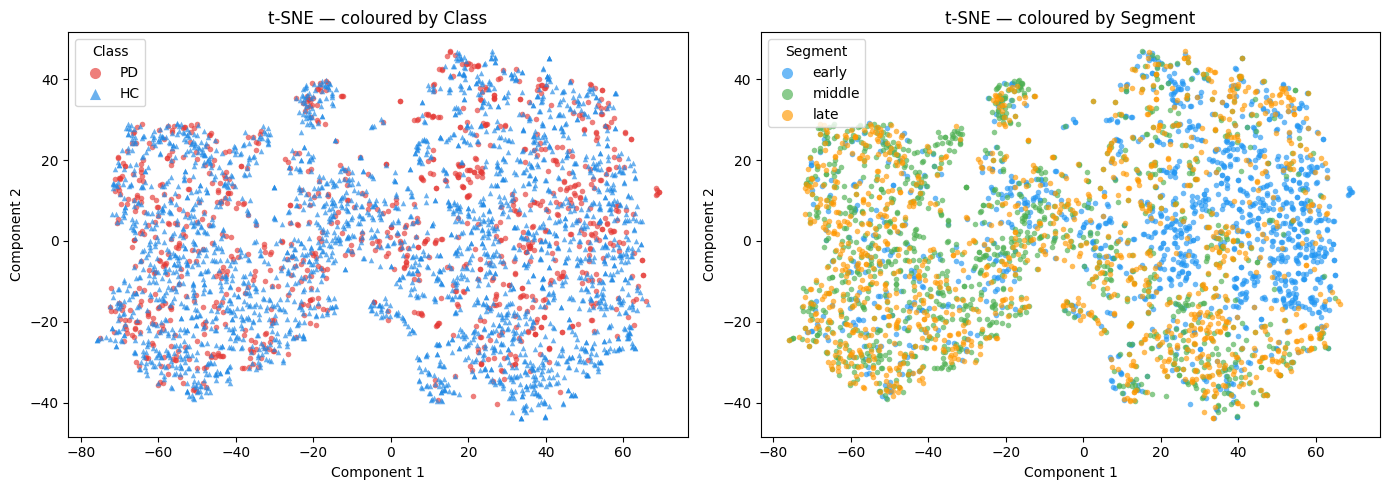


Plot saved  ->  /home/bs00956/Desktop/Personal/PD/Pipeline-Implementation/Wav2Vec2/plots/tsne_combined.png


In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler as SS

CLASS_COLORS  = {"PD": "#E53935", "HC": "#1E88E5"}
CLASS_MARKERS = {"PD": "o",       "HC": "^"}
SEG_COLORS    = {"early": "#2196F3", "middle": "#4CAF50", "late": "#FF9800"}

def load_for_viz(df):
    X, labels, segs = [], [], []
    for _, row in df.iterrows():
        p = row["embedding_path"]
        if os.path.isfile(p):
            X.append(np.load(p))
            labels.append(row["class"])
            segs.append(row.get("segment", "agg"))
    return np.stack(X), np.array(labels), np.array(segs)

meta_df = pd.read_csv(META_PATH)
X, labels, segs = load_for_viz(meta_df)
print(f"Running t-SNE on {len(X)} embeddings (dim={X.shape[1]})...")

coords = TSNE(
    n_components=2, perplexity=30, random_state=42,
    init="pca", max_iter=1000               # n_iter renamed to max_iter in sklearn >= 1.4
).fit_transform(SS().fit_transform(X))

os.makedirs(PLOTS_DIR, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in ["PD", "HC"]:
    m = labels == cls
    axes[0].scatter(coords[m, 0], coords[m, 1],
                    label=cls, alpha=0.65, s=16,
                    color=CLASS_COLORS[cls], marker=CLASS_MARKERS[cls], linewidths=0)
axes[0].set_title("t-SNE — coloured by Class")
axes[0].set_xlabel("Component 1"); axes[0].set_ylabel("Component 2")
axes[0].legend(title="Class", markerscale=2)

for seg in SEGMENTS:
    m = segs == seg
    axes[1].scatter(coords[m, 0], coords[m, 1],
                    label=seg, alpha=0.65, s=16,
                    color=SEG_COLORS[seg], linewidths=0)
axes[1].set_title("t-SNE — coloured by Segment")
axes[1].set_xlabel("Component 1"); axes[1].set_ylabel("Component 2")
axes[1].legend(title="Segment", markerscale=2)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "tsne_combined.png")
plt.savefig(out, dpi=150)
plt.show()
print(f"\nPlot saved  ->  {out}")